### Import Modules

In [1]:
# Standard Library
import random
from datetime import datetime, timezone
from os import environ

# Packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine, text

### Constants & Config

In [2]:
# Environment
load_dotenv()

# SQL
ENGINE = create_engine(
    f"postgresql://{environ['POSTGRES_USER']}:{environ['POSTGRES_PASSWORD']}"
    f"@{environ['POSTGRES_HOST']}:{environ['POSTGRES_PORT']}/{environ['FRAUD_DETECTION_DB_NAME']}"
)

# Reproducibility
RANDOM_STATE = 42
RNG = np.random.default_rng(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

### Read data from SQL

In [3]:
# Start and end times set for CSV dataset
initial_data_start_time = datetime(2019, 1, 1, tzinfo=timezone.utc)
initial_data_end_time = datetime(2019, 1, 3, tzinfo=timezone.utc)

df = pd.read_sql(text(f"""
    SELECT DISTINCT ON (transaction_id)
        is_fraud,
        amount,
        transaction_timestamp,
        {",".join([f"v{i}" for i in range(1, 29)])}
    FROM transaction_inferences
    WHERE transaction_timestamp BETWEEN :start_time AND :end_time
    ORDER BY
        transaction_id,
        random()
    """),
    ENGINE,
    params={
        "start_time": initial_data_start_time,
        "end_time": initial_data_end_time,
    },
)

# Convert bool to int64
df["is_fraud"] = df["is_fraud"].astype("int64")
# Convert datetime64[ns, UTC] to seconds (int64)
df["transaction_inferences"] = (
    pd.to_datetime(
        df["transaction_inferences"],
        utc=True
    )
    .astype("datetime64[s, UTC]")
    .astype("int64")
)

print(f"Loaded {len(df):,} rows")
df.head()

Loaded 284,807 rows


,transaction_timestamp,amount,v1,v2,v3,v4,v5,v6,v7,v8,...,v20,v21,v22,v23,v24,v25,v26,v27,v28,is_fraud
0,1546333158,45.00,1.079365,0.048546,1.338433,1.357557,-1.050052,-0.589543,-0.409676,-0.037649,...,-0.003219,0.156442,0.434422,-0.007908,0.733404,0.305933,-0.388239,0.060015,0.052250,0
1,1546446699,117.00,1.782987,-0.834805,-0.574236,0.201291,-0.722902,-0.216241,-0.579421,0.060928,...,0.031025,0.264445,0.599855,0.041227,-0.361393,-0.386450,0.646388,-0.063887,-0.044458,0
2,1546352943,8.99,-0.825850,0.813128,2.426074,-0.035323,-0.474062,-0.317309,0.231861,0.277409,...,0.031806,-0.045753,-0.119447,-0.099858,0.361219,-0.029777,0.278525,0.281630,0.133343,0
3,1546353258,10.00,1.256677,0.208935,0.171589,1.147307,-0.238629,-0.633712,0.022575,-0.081581,...,-0.214588,0.023077,0.030996,-0.157399,-0.153528,0.684891,-0.244892,0.006347,0.014574,0
4,1546427755,1.00,2.045226,0.455282,-2.363337,1.477942,0.914136,-0.971208,0.571373,-0.253545,...,-0.323599,-0.061378,-0.018174,0.025248,0.513164,0.444503,-0.514202,-0.008667,-0.026661,0


### Exploratory Data Analysis

Shape: (284807, 31)
Null Total: 0


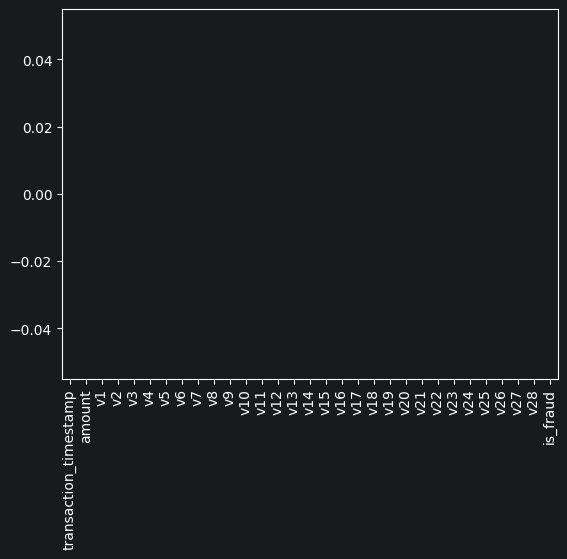

In [4]:
# Basic overview
print(f"Shape: {df.shape}")
print(f"Null Total: {df.isnull().sum().sum()}")
df.isnull().sum().plot(kind="bar")
plt.show()

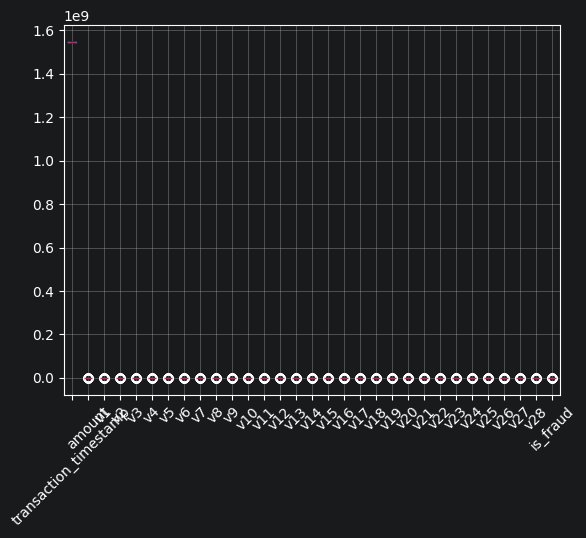

In [5]:
# Feature Distribution
df.boxplot()
plt.xticks(rotation=45)
plt.show()

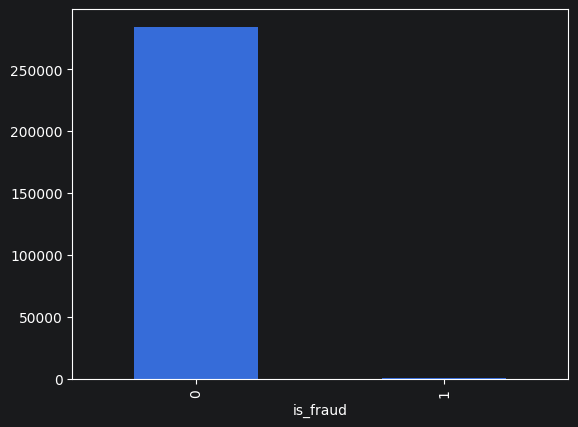

In [6]:
# Class distribution
df["is_fraud"].value_counts().plot(kind="bar")
plt.show()

### Handling Imbalanced Classes

In [20]:
x = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

train_x, test_x, train_y, test_y = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

smote = SMOTE(random_state=RANDOM_STATE)
train_x_smote, train_y_smote = smote.fit_resample(train_x, train_y)

# Collect split data
data_sets = {
    "train_x": train_x_smote,
    "train_y": train_y_smote,
    "test_x": test_x,
    "test_y": test_y,
}

# Save to sql (ACID transaction)
with ENGINE.begin() as connection:
    for suffix, data in data_sets.items():
        data.to_sql(
            f"preprocessed_transactions_{suffix}",
            con=connection,
            if_exists="replace",
            index=False,
        )

print(f"Train classes before SMOTE\n{pd.Series(train_y).value_counts()}\n")
print(f"Train classes after SMOTE\n{train_y_smote.value_counts()}\n")
pd.concat(
    [
        pd.concat([train_x_smote, train_y_smote], axis=1),
        pd.concat([test_x, test_y], axis=1),
    ]
).head()

Train classes before SMOTE
is_fraud
0    227451
1       394
Name: count, dtype: int64

Train classes after SMOTE
is_fraud
0    227451
1    227451
Name: count, dtype: int64



,transaction_timestamp,amount,v1,v2,v3,v4,v5,v6,v7,v8,...,v20,v21,v22,v23,v24,v25,v26,v27,v28,is_fraud
0,1546345919,321.95,-1.348690,0.900014,1.984170,-0.008635,-1.661308,1.145644,1.704313,0.030943,...,-0.513417,0.042434,0.197953,-0.214079,0.193509,0.139526,-0.566548,-0.095270,-0.060117,0
1,1546442725,1.29,-0.798195,0.887285,1.339229,-1.053335,0.696300,-1.091852,1.204520,-0.183783,...,-0.135801,-0.285071,-0.901945,-0.307787,0.035606,0.562455,0.235007,-0.067150,0.037503,0
2,1546343889,93.23,1.030646,-0.573638,1.217802,0.308482,-1.452995,-0.621280,-0.553976,-0.015796,...,0.113430,-0.042442,-0.109730,0.022977,0.798816,0.045704,0.960357,-0.047937,0.034912,0
3,1546436848,29.56,2.030186,0.234072,-2.514668,0.769865,0.730890,-0.943608,0.242111,-0.264767,...,-0.090425,-0.049601,0.156223,-0.150498,-0.912593,0.283439,0.774545,-0.038409,-0.016644,0
4,1546451631,3.08,-0.478713,1.177304,-0.941223,-0.902117,1.314958,0.130906,0.692979,-0.070038,...,0.076935,0.042747,0.394439,-0.043010,-0.247729,-0.826477,0.221383,-0.659592,-0.261492,0
